# Data preparation ASTER08 for lake_6 Kangaarsuup Tasersua
After completing the data download and having manually classified cloud-impacted lake scenes, these scenes can now be filtered and data can be prepared to extract the lake surface water statistics. 

This script implements:
- 500m inwards buffer from the lake shoreline from 2025 from How et al. 2025 the GrIML inventory
- usese the manually classified cloud table and discards the scenes classified as not clear sky
- converts from decimal degrees in K to celsius degrees
- creates statistics for each scene: mean, median, std, bootsrapped CI, and counts the num of pixels per scene


In [1]:
import xarray
import rioxarray
import pandas as pd
import geopandas as gpd
import datetime
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import statsmodels
import rasterio

# for plotting with basemap
from rasterio.plot import show  

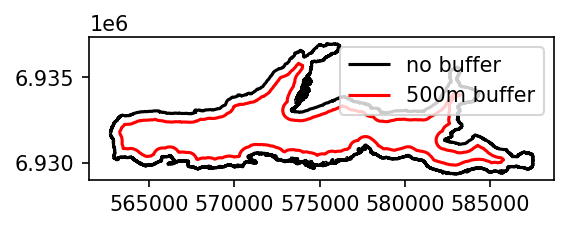

In [ ]:
# read the lake shoreline, and apply a buffer of 500m
lake = gpd.read_file('lake_shoreline.shp')
lake_32622 = lake.to_crs(epsg=32622)
lake_32622_buffered = lake_32622.buffer(-500) # unit: UTM --> N and E in m

# check by plotting:

fig, ax = plt.subplots(figsize = (4, 4))

lake_32622.boundary.plot(ax = ax, color = "black", label = "no buffer")
lake_32622_buffered.boundary.plot(ax = ax, color = "red", label = "500m buffer")
plt.legend()
plt.show()


The `.csv` file called "cloud_labels_finished.csv" contains the file names (path string for folder) and labels: 
- clear
- partly cloudy
- cloudy
- not in scene 



In [ ]:
# read file and subset to only clear sky conditions above the lake
cloud_table = pd.read_csv('cloud_labels_finished.csv')
filtered_table = cloud_table[cloud_table['label'] == 'clear']
print(len(filtered_table))

# read only the files that are cloud free and perform data analysis on it


66


#### a small helper function to get the date from the file string


In [32]:
from pathlib import Path
from datetime import datetime
import re

# function to get a datetime oject 
def extract_aster_acquisition_datetime(filename):
    name = Path(filename).name
    pattern = r"^AST_\w+_(\d{3})(\d{14})_\d{14}"
    match = re.match(pattern, name)

    if not match:
        raise ValueError(f"Not a recognized ASTER filename: {name}")

    acquisition = match.group(2)

    # Acquisition timestamp is MMDDYYYYHHMMSS
    return datetime.strptime(acquisition, "%m%d%Y%H%M%S")


### create the statistics first for only one `.tif`file - then loop
Unfortunately, I cannot simply create an `xarray` DataArray/DataSet, since the ASTER08 images are rotated and not north up. I dont want to do this here (although there is a description how to reproject and rotate everything in this ressource: https://github.com/nasa/ASTER-Data-Resources/blob/main/python/tutorials/Exploring_AST_08_Surface_Kinetic_Temperature.ipynb). Therefore, I simply use a loop - although this is slow, but the number of iterations is still feasible. 

C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(


Temp mean:-0.5395216941833496
Temp median:[-0.5499878]
Temp std:[0.63508254]
Num pixels:[5341]
date of image:2008-03-08, Month: 3


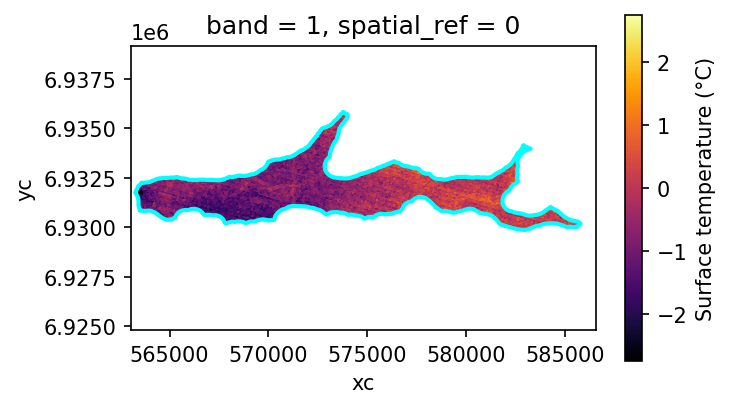

In [41]:
# read data file
tif = rioxarray.open_rasterio(filtered_table.file[5]) # open raster 

# mask out NA values decoded as 2000
tif = tif.where(tif != 2000)

# convert K in degree celsius
tif = (tif * 0.1) - 273.15 # scale to celsius

# clip by lake boundaries
tif_clipped = tif.rio.clip(lake_32622_buffered.geometry, lake_32622_buffered.crs)
tif_clipped

# count pixels
num_pixels = tif_clipped.count(dim = ['x', 'y'])

# mean 
mean = tif_clipped.mean(dim = ['x', 'y'])

# median
median = tif_clipped.median(dim = ['x', 'y'])

# std
std_tif = tif_clipped.std(dim = ['x', 'y'])

# date
date = extract_aster_acquisition_datetime(filename = filtered_table.file[0])

# plot for inspection
fig, ax = plt.subplots(figsize= (5, 3))
from rasterio.plot import show
tif_clipped.plot(ax=ax,
    x="xc",y="yc",
    cmap="inferno",
    add_colorbar=True,
    cbar_kwargs={"label": "Surface temperature (°C)"})
        
        # lake shoreline
lake_32622_buffered.plot(
            ax=ax,
            facecolor="none",
            edgecolor="cyan",
            linewidth=2)
tif_clipped.coords

print(f'Temp mean:{mean.item()}')
print(f'Temp median:{median.values}')
print(f'Temp std:{std_tif.values}')
print(f'Num pixels:{num_pixels.values}')
print(f'date of image:{date.date()}, Month: {date.month}')


In [50]:
import rioxarray
import pandas as pd

results = []

for file in filtered_table.file:
    
    # Read raster
    tif = rioxarray.open_rasterio(file)
    
    # Mask out NA values decoded as 2000
    tif = tif.where(tif != 2000)
    
    # Convert Kelvin (scaled by 0.1) to Celsius
    tif = (tif * 0.1) - 273.15
    
    # Clip by lake boundaries
    tif_clipped = tif.rio.clip(
        lake_32622_buffered.geometry,
        lake_32622_buffered.crs
    )
    
    # Calculate statistics
    num_pixels = tif_clipped.count(dim=['x', 'y']).item()
    mean = tif_clipped.mean(dim=['x', 'y']).item()
    median = tif_clipped.median(dim=['x', 'y']).item()
    std_tif = tif_clipped.std(dim=['x', 'y']).item()
    
    # Extract acquisition date from the current file
    date = extract_aster_acquisition_datetime(filename=file)
    
    # Store results
    results.append({
        'file': file,
        'datetime': date,
        'n_valid_pixels': num_pixels,
        'lst_mean_C': mean,
        'lst_median_C': median,
        'lst_std': std_tif
    })

# Convert list of dictionaries to DataFrame
df = pd.DataFrame(results)



C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\rioxarray\rioxarray.py:431: UserWarning: Transform that is non-rectilinear or with rotation found. Unable to recalculate.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs

In [51]:
# save table for analysis with other tables
df.to_csv("ASTER08_LST_lake_6.csv", index = True)